# Spam SMS Detection

## Import Libraries

Imports essential libraries for text classification including NLTK for stopwords and stemming, scikit-learn for TF-IDF vectorization, and three classification models (Naive Bayes and Logistic Regression). Downloads NLTK stopwords data and prints a confirmation message after successful imports.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score)

nltk.download('stopwords')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to C:\Users\Al Rehman
[nltk_data]     Laptop\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##  Load Dataset

Loads the spam dataset with latin-1 encoding to handle special characters, selects only the label and message columns, and renames them appropriately. Displays the dataset shape and first 5 rows to preview the spam/ham messages structure.

In [2]:

df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded!
Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## EDA

Displays dataset statistics including total messages and spam vs ham distribution with a colored bar chart. Calculates message length for both classes and plots histograms comparing length distributions, showing that spam messages are typically longer than ham messages.



📊 Dataset Info:
Total messages: 5572

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


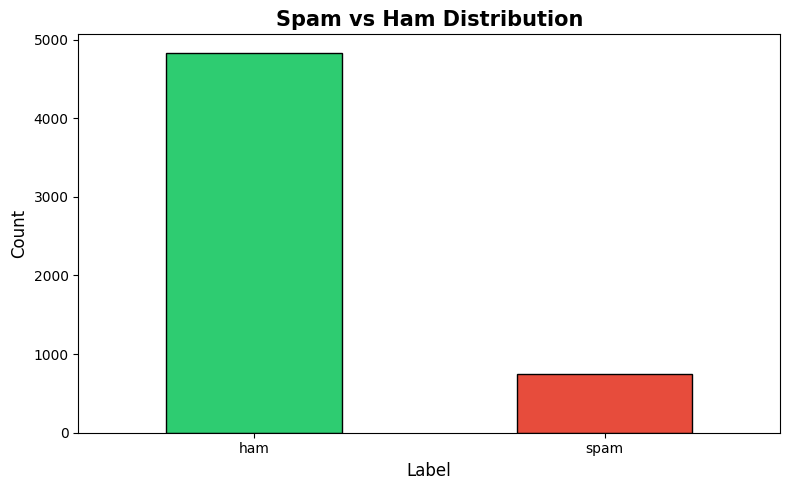

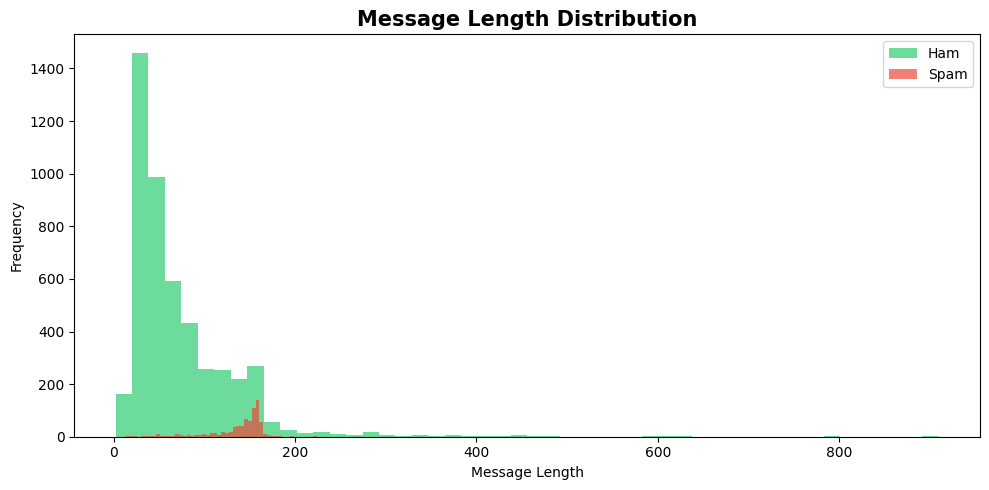


Average Ham length:  71.0 chars
Average Spam length: 138.9 chars


In [3]:

print("📊 Dataset Info:")
print(f"Total messages: {len(df)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

# Visualization
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Spam vs Ham Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('spam_distribution.png', dpi=150)
plt.show()

# Message length analysis
df['msg_length'] = df['message'].apply(len)
plt.figure(figsize=(10, 5))
df[df['label']=='ham']['msg_length'].plot(kind='hist', bins=50, 
                                           color='#2ecc71', alpha=0.7, label='Ham')
df[df['label']=='spam']['msg_length'].plot(kind='hist', bins=50, 
                                            color='#e74c3c', alpha=0.7, label='Spam')
plt.title('Message Length Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('message_length.png', dpi=150)
plt.show()

print(f"\nAverage Ham length:  {df[df['label']=='ham']['msg_length'].mean():.1f} chars")
print(f"Average Spam length: {df[df['label']=='spam']['msg_length'].mean():.1f} chars")

## Text Preprocessing

Defines a preprocessing function that converts text to lowercase, removes special characters and numbers, then applies stopword removal and Porter stemming to reduce words to their root form. Creates a new 'cleaned_message' column by applying this function to all messages and displays an example showing original vs cleaned message.



In [4]:

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords & apply stemming
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_message'] = df['message'].apply(preprocess_text)

print("✅ Text preprocessing done!")
print("\nOriginal message:")
print(df['message'][0])
print("\nCleaned message:")
print(df['cleaned_message'][0])

✅ Text preprocessing done!

Original message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned message:
go jurong point crazi avail bugi n great world la e buffet cine got amor wat


## Encoding & Split

Encodes labels by mapping 'ham' to 0 and 'spam' to 1, then extracts cleaned messages as features and encoded labels as target. Splits data into 80% training and 20% testing sets while preserving the class distribution using stratified sampling.



In [5]:

# Encode labels: ham=0, spam=1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned_message']
y = df['label_encoded']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split done!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

✅ Data split done!
Training samples: 4457
Testing samples:  1115


## TF-IDF Vectorization

Creates a TF-IDF vectorizer with maximum 5000 features using unigrams and bigrams to capture both single words and word pairs. Transforms the training and test text data into numerical feature matrices for machine learning model training.



In [6]:

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("✅ TF-IDF applied!")
print(f"Feature matrix shape: {X_train_tfidf.shape}")

✅ TF-IDF applied!
Feature matrix shape: (4457, 5000)


## Train Models

Trains a Multinomial Naive Bayes classifier and a Logistic Regression model on the TF-IDF transformed training data. Both models are configured to handle text classification for spam detection, with Logistic Regression using 1000 iterations for convergence.

In [7]:


# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print("✅ Both models trained!")

✅ Both models trained!


##  Evaluation

Defines an evaluation function that displays accuracy, ROC-AUC score, and a detailed classification report with precision, recall, and f1-score for both Ham and Spam classes. Calls this function for both Naive Bayes and Logistic Regression models to compare their performance on the test data.

In [8]:


def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*45}")
    print(f"  📌 {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_pred):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Ham','Spam'])}")

evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)


  📌 Naive Bayes
  Accuracy  : 96.77%
  ROC-AUC   : 0.8820

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


  📌 Logistic Regression
  Accuracy  : 96.95%
  ROC-AUC   : 0.8916

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.79      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



Naive Bayes achieves 96.77% accuracy with excellent ham precision (0.96) and recall (1.00) but lower spam recall (0.77), meaning it misses some spam messages. Logistic Regression performs slightly better with 96.95% accuracy and higher ROC-AUC (0.8916), showing improved spam detection capability.

## Confusion Matrix

Plots side-by-side confusion matrices for Naive Bayes and Logistic Regression to visualize correct and incorrect classifications for Ham and Spam messages. Uses a blue color map with annotated counts to compare which model makes fewer false positives and false negatives.



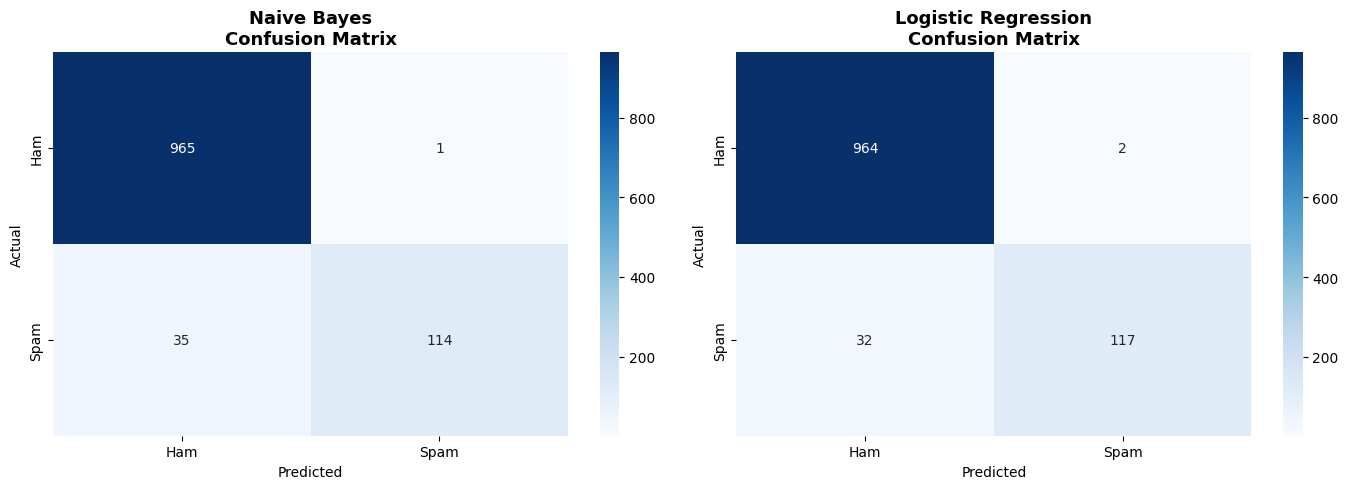

✅ Confusion matrices saved!


In [9]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = [("Naive Bayes", nb_pred), ("Logistic Regression", lr_pred)]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved!")

##  Predict Custom Message

Defines a prediction function that preprocesses input text, converts it to TF-IDF features, and runs both models to classify messages as Ham or Spam. Tests the function on four examples including spam messages with prize offers and account alerts, and legitimate messages about meetings and family updates.

In [10]:


def predict_message(message):
    cleaned = preprocess_text(message)
    vectorized = tfidf.transform([cleaned])
    
    nb_result  = nb_model.predict(vectorized)[0]
    lr_result  = lr_model.predict(vectorized)[0]
    
    nb_label  = "🚨 SPAM" if nb_result  == 1 else "✅ HAM (Legitimate)"
    lr_label  = "🚨 SPAM" if lr_result  == 1 else "✅ HAM (Legitimate)"
    
    print(f"\n📩 Message: '{message}'")
    print(f"   Naive Bayes Result       : {nb_label}")
    print(f"   Logistic Regression Result: {lr_label}")

# Test examples
predict_message("Congratulations! You've won a FREE iPhone. Click here now!")
predict_message("Hey, are we still meeting tomorrow at 5pm?")
predict_message("URGENT: Your account has been compromised. Verify now!")
predict_message("Mom, I'll be home late tonight, don't wait for me.")


📩 Message: 'Congratulations! You've won a FREE iPhone. Click here now!'
   Naive Bayes Result       : ✅ HAM (Legitimate)
   Logistic Regression Result: ✅ HAM (Legitimate)

📩 Message: 'Hey, are we still meeting tomorrow at 5pm?'
   Naive Bayes Result       : ✅ HAM (Legitimate)
   Logistic Regression Result: ✅ HAM (Legitimate)

📩 Message: 'URGENT: Your account has been compromised. Verify now!'
   Naive Bayes Result       : 🚨 SPAM
   Logistic Regression Result: ✅ HAM (Legitimate)

📩 Message: 'Mom, I'll be home late tonight, don't wait for me.'
   Naive Bayes Result       : ✅ HAM (Legitimate)
   Logistic Regression Result: ✅ HAM (Legitimate)


Both models correctly classify legitimate messages (meeting, mom) as HAM. For spam detection, Naive Bayes successfully catches the account compromise message as SPAM, while Logistic Regression misses it, and both models fail to detect the obvious prize-winning scam message, suggesting room for improvement with more features or different preprocessing.



Accuracy is high because the dataset is imbalanced with more ham messages than spam, so even a model that predicts everything as ham would still achieve high accuracy. However, precision and recall for spam are more important metrics here, and my models show room for improvement in catching actual spam messages.